1. 先计算每一个因子的每日变化百分比.  
2. 根据时间序列切分数据集和验证集.用TimeSeriesSplit扩展窗口.  
3. 进行标准化.因为不同因子之间的单位不一样,标准化后便于比较因子影响.且先进行标准化,会让以前的数据被未来的数据标准化,存在数据泄露的问题.  
4. 编写一个测试的函数,之后传入不同的模型即可  
5. 运用决策树,SVR,再对SVR进行调参(Hyperparameter Tuning).随机森林,然后再调参.Lasso and Ridge回归,Bayesian Ridge.Gradient Boosting 回归.SGD.  
6. 比较所有模型的RMSE  
以上为不选择特征的的预测流程.  



In [ ]:
加上技术指标后,再作为新的数据,看看是否有用,提高模型的预测准确率.

1. 根据上面的步骤,选择有最低RMSE的模型进行特征选择.  
2. 原项目采用了Lasso,类似于OLS,但是它会对多因子进行惩罚,将一些系数设置为0,来简化模型.原项目数据集没有用的东西较多,比如标普,道琼斯的开盘收盘价格等等,我复现没有这个问题.Lasso会对系数大小进行惩罚,不进行标准化由于单位不同会造成很大的影响.  
当你有一大堆数据,你不知道哪个有用的时候,全部喂进去,先进行拟合,对系数缩小进行惩罚,最后一些不显著的会变成0.但是如果模型本身简单和正确,普通OLS估计的值更好.  
3. 用筛选出来的数据在进行测试.比对多变量和精简变量的RMSE和R^2表现(选一个就够).
4. 在多因子模型和选择因子模型中,选择三个最好的,分别结合起来,进行对比.本项目中选用只是三个数取平均,之后也可以再进行一次学习,让每个模型的权重不一样.  
5. 选中多个模型进行比较,多次切分数据集进行训练,取一个平均值.

In [1]:
from utils.common import *

In [2]:
stock_data = pd.read_pickle('data/stock_data.pkl')
elements_data = pd.read_pickle('data/elements_data.pkl')

In [6]:
display(stock_data.keys())

dict_keys(['紫金矿业', '山东黄金', '中金黄金', '赤峰黄金', '山金国际', '湖南黄金', '恒邦股份', '招金黄金'])

In [9]:
display(elements_data.keys())

Index(['Dollar_index', 'cn_10y_rate', 'us_10y_rate', 'brent', 'copper'], dtype='object')

In [11]:
all_index_dic = pd.read_pickle('./src/pickle/all_index_dic.pkl')

In [12]:
display(all_index_dic.keys())

Index(['CSI_300', 'A_500', 'metal', 'equal', 'weight', 'cap', 'gold'], dtype='object')

In [56]:
zijin = stock_data['紫金矿业']

In [57]:
A_500 = all_index_dic['A_500']

In [87]:
# gold = all_index_dic['gold']
copper = elements_data['copper']

In [59]:
Dollar_index = elements_data['Dollar_index']
cn_10y_rate = elements_data['cn_10y_rate']
us_10y_rate = elements_data['us_10y_rate']
brent = elements_data['brent']

In [19]:
zijin.tail()

,date,open,high,low,close,volume,amount,outstanding_share,turnover
3422,2026-07-20,28.36,29.45,28.29,29.35,275768250.0,7.992030e+09,2.060179e+10,0.013386
3423,2026-07-21,29.95,30.33,29.13,30.21,342666967.0,1.019429e+10,2.060179e+10,0.016633
3424,2026-07-22,30.81,32.79,30.81,32.20,526165813.0,1.685158e+10,2.060179e+10,0.025540
3425,2026-07-23,32.52,33.68,31.92,33.06,439447611.0,1.449661e+10,2.060179e+10,0.021331
3426,2026-07-24,31.74,32.09,30.97,31.51,401039285.0,1.260250e+10,2.060179e+10,0.019466


In [20]:
A_500.tail()

2026-07-17    2024.406692
2026-07-20    2040.782832
2026-07-21    2119.573044
2026-07-22    2106.458340
2026-07-23    2110.372354
Name: A_500, dtype: float64

In [21]:
gold.tail()

2026-07-17    2517.851587
2026-07-20    2516.345719
2026-07-21    2554.495967
2026-07-22    2602.058122
2026-07-23    2539.122935
Name: gold, dtype: float64

In [22]:
Dollar_index.tail()

,Close
Date,
2026-07-17 00:00:00-04:00,100.750000
2026-07-20 00:00:00-04:00,100.989998
2026-07-21 00:00:00-04:00,101.180000
2026-07-22 00:00:00-04:00,101.139999
2026-07-23 00:00:00-04:00,101.430000


In [23]:
zijin.shape

(3427, 9)

In [24]:
A_500.shape

(3334,)

In [26]:
gold.shape

(3334,)

In [27]:
Dollar_index.shape

(3572, 1)

In [28]:
cn_10y_rate.shape

(3786, 1)

In [29]:
us_10y_rate.shape

(3786, 2)

In [30]:
brent.shape

(3707, 1)

In [34]:
copper.shape

(2590,)

为什么他们的数量都不一样?可能存在数据缺失的现象,将它们合并再进行处理.

In [73]:
zijin = zijin.set_index('date')

In [74]:
df_all = zijin['close']

In [75]:
df_all = pd.concat([df_all, A_500], axis=1)

In [76]:
df_all = pd.concat([df_all, gold,], axis=1)

In [79]:
# us_10y_rate = us_10y_rate.set_index('日期')

In [80]:
Dollar_index.index = pd.to_datetime(Dollar_index.index).tz_localize(None)
cn_10y_rate.index = pd.to_datetime(cn_10y_rate.index).tz_localize(None)
us_10y_rate.index = pd.to_datetime(us_10y_rate.index).tz_localize(None)
brent.index = pd.to_datetime(brent.index).tz_localize(None)
copper.index = pd.to_datetime(copper.index).tz_localize(None)

In [81]:
df_all = pd.concat([df_all,Dollar_index,cn_10y_rate,us_10y_rate,brent,copper,gold], axis=1)

In [82]:
display(df_all)

,close,A_500,gold,Close,中国国债收益率10年,美国国债收益率10年,DCOILBRENTEU,close,gold
2012-05-02,4.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-05-03,4.37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-05-04,4.38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-05-07,4.39,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-05-08,4.38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2026-08-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,669.90,NaN
2026-08-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,669.20,NaN
2026-08-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,663.95,NaN
2026-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,668.80,NaN


In [84]:
df_all = df_all[df_all.index >= '2012-05-09']
df_all = df_all[df_all.index<='2026-07-23']

In [85]:
display(df_all)

,close,A_500,gold,Close,中国国债收益率10年,美国国债收益率10年,DCOILBRENTEU,close,gold
2012-05-09,4.28,1000.000000,1000.000000,80.080002,3.5414,1.87,111.89,NaN,1000.000000
2012-05-10,4.26,1000.166229,1000.878474,80.110001,3.5287,1.89,112.24,NaN,1000.878474
2012-05-11,4.20,993.645535,993.662561,80.279999,3.4907,1.84,112.50,NaN,993.662561
2012-05-14,4.15,986.340876,979.230736,80.599998,3.4461,1.78,110.79,NaN,979.230736
2012-05-15,4.14,986.907436,976.846393,81.220001,3.4050,1.76,111.40,NaN,976.846393
...,...,...,...,...,...,...,...,...,...
2026-07-17,28.36,2024.406692,2517.851587,100.750000,1.7404,4.55,85.01,626.95,2517.851587
2026-07-20,29.35,2040.782832,2516.345719,100.989998,1.7453,4.60,86.99,633.95,2516.345719
2026-07-21,30.21,2119.573044,2554.495967,101.180000,1.7450,4.63,93.85,652.85,2554.495967
2026-07-22,32.20,2106.458340,2602.058122,101.139999,1.7297,4.67,94.12,649.10,2602.058122


需要对列名进行更改,且为什么copper缺了很多数据

In [88]:
display(copper)

date
2016-09-01    208.05
2016-09-02    207.75
2016-09-05    208.25
2016-09-06    209.40
2016-09-07    209.90
               ...  
2026-08-26    669.90
2026-08-27    669.20
2026-08-28    663.95
2026-08-31    668.80
2026-09-01    670.50
Name: close, Length: 2590, dtype: float64

看来是01这个笔记没有处理好,从2016年开始了.

In [89]:
copper = pd.read_csv('./data/Copper Futures Historical Data.csv', index_col=0)

In [96]:
copper.index = pd.to_datetime(copper.index)
# copper = copper.set_index('Date')
copper = copper.sort_index(ascending=True)
copper = copper[copper.index >= '2012-05-09']
copper = copper[copper.index<='2026-07-23']
copper = copper.rename(columns={'Price': 'Copper Futures Price'})
copper = copper['Copper Futures Price']

In [117]:
# del df_all
df_all = pd.concat([zijin,A_500,Dollar_index,cn_10y_rate,us_10y_rate,brent,copper,gold], axis=1)

In [121]:
display(df_all)

,open,high,low,close,volume,amount,outstanding_share,turnover,A_500,Close,中国国债收益率10年,美国国债收益率10年,DCOILBRENTEU,Copper Futures Price,gold
2012-05-02,4.35,4.44,4.31,4.40,103994416.0,4.565610e+08,1.580380e+10,0.006580,1000.000000,80.080002,3.5414,1.87,111.89,3.6595,1000.000000
2012-05-03,4.38,4.40,4.35,4.37,57981480.0,2.532650e+08,1.580380e+10,0.003669,1000.000000,80.080002,3.5414,1.87,111.89,3.6595,1000.000000
2012-05-04,4.33,4.38,4.31,4.38,58086300.0,2.524024e+08,1.580380e+10,0.003675,1000.000000,80.080002,3.5414,1.87,111.89,3.6595,1000.000000
2012-05-07,4.34,4.40,4.32,4.39,64803776.0,2.836709e+08,1.580380e+10,0.004101,1000.000000,80.080002,3.5414,1.87,111.89,3.6595,1000.000000
2012-05-08,4.38,4.39,4.34,4.38,62989116.0,2.745420e+08,1.580380e+10,0.003986,1000.000000,80.080002,3.5414,1.87,111.89,3.6595,1000.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-20,28.36,29.45,28.29,29.35,275768250.0,7.992030e+09,2.060179e+10,0.013386,2040.782832,100.989998,1.7453,4.60,86.99,6.3410,2516.345719
2026-07-21,29.95,30.33,29.13,30.21,342666967.0,1.019429e+10,2.060179e+10,0.016633,2119.573044,101.180000,1.7450,4.63,93.85,6.5525,2554.495967
2026-07-22,30.81,32.79,30.81,32.20,526165813.0,1.685158e+10,2.060179e+10,0.025540,2106.458340,101.139999,1.7297,4.67,94.12,6.4935,2602.058122
2026-07-23,32.52,33.68,31.92,33.06,439447611.0,1.449661e+10,2.060179e+10,0.021331,2110.372354,101.430000,1.7325,4.71,105.32,6.3435,2539.122935


In [122]:
df_all = df_all.drop(columns=['open','high','low','volume','amount','outstanding_share','turnover'])

In [123]:
df_all = df_all[df_all.index >= '2012-05-09']
df_all = df_all[df_all.index<='2026-07-23']

In [124]:
df_all.rename(columns={
    'close': 'Zijin',
    'Close': 'Dollar Index',
    '中国国债收益率10年':'cn_10y_rate',
    '美国国债收益率10年':'us_10y_rate',
    'DCOILBRENTEU':'brent',
    'gold':'Gold Futures Price',
},inplace=True) 

In [125]:
display(df_all)

,Zijin,A_500,Dollar Index,cn_10y_rate,us_10y_rate,brent,Copper Futures Price,Gold Futures Price
2012-05-09,4.28,1000.000000,80.080002,3.5414,1.87,111.89,3.6595,1000.000000
2012-05-10,4.26,1000.166229,80.110001,3.5287,1.89,112.24,3.6905,1000.878474
2012-05-11,4.20,993.645535,80.279999,3.4907,1.84,112.50,3.6480,993.662561
2012-05-14,4.15,986.340876,80.599998,3.4461,1.78,110.79,3.5540,979.230736
2012-05-15,4.14,986.907436,81.220001,3.4050,1.76,111.40,3.5175,976.846393
...,...,...,...,...,...,...,...,...
2026-07-17,28.36,2024.406692,100.750000,1.7404,4.55,85.01,6.2650,2517.851587
2026-07-20,29.35,2040.782832,100.989998,1.7453,4.60,86.99,6.3410,2516.345719
2026-07-21,30.21,2119.573044,101.180000,1.7450,4.63,93.85,6.5525,2554.495967
2026-07-22,32.20,2106.458340,101.139999,1.7297,4.67,94.12,6.4935,2602.058122


对于股票的价格,和指数,空缺的部分,我们直接删除.对于美元指数,国债收益率,原油价格,铜价金价我们用用bfill

In [127]:
df_all = df_all.dropna(subset=['Zijin', 'A_500'])

In [128]:
df_all = df_all.bfill()

# 反思:  
### 不应该用未来的值来填充过去,应该用过去的值来填充,以防数据泄露

In [129]:
display(df_all)

,Zijin,A_500,Dollar Index,cn_10y_rate,us_10y_rate,brent,Copper Futures Price,Gold Futures Price
2012-05-09,4.28,1000.000000,80.080002,3.5414,1.87,111.89,3.6595,1000.000000
2012-05-10,4.26,1000.166229,80.110001,3.5287,1.89,112.24,3.6905,1000.878474
2012-05-11,4.20,993.645535,80.279999,3.4907,1.84,112.50,3.6480,993.662561
2012-05-14,4.15,986.340876,80.599998,3.4461,1.78,110.79,3.5540,979.230736
2012-05-15,4.14,986.907436,81.220001,3.4050,1.76,111.40,3.5175,976.846393
...,...,...,...,...,...,...,...,...
2026-07-17,28.36,2024.406692,100.750000,1.7404,4.55,85.01,6.2650,2517.851587
2026-07-20,29.35,2040.782832,100.989998,1.7453,4.60,86.99,6.3410,2516.345719
2026-07-21,30.21,2119.573044,101.180000,1.7450,4.63,93.85,6.5525,2554.495967
2026-07-22,32.20,2106.458340,101.139999,1.7297,4.67,94.12,6.4935,2602.058122


---  
以上为数据的处理部分,下面正式开始


# 1 将数据处理成百分比形式

In [132]:
df_all_pct = df_all.pct_change()
display(df_all_pct)

,Zijin,A_500,Dollar Index,cn_10y_rate,us_10y_rate,brent,Copper Futures Price,Gold Futures Price
2012-05-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-05-10,-0.004673,0.000166,0.000375,-0.003586,0.010695,0.003128,0.008471,0.000878
2012-05-11,-0.014085,-0.006520,0.002122,-0.010769,-0.026455,0.002316,-0.011516,-0.007210
2012-05-14,-0.011905,-0.007351,0.003986,-0.012777,-0.032609,-0.015200,-0.025768,-0.014524
2012-05-15,-0.002410,0.000574,0.007692,-0.011927,-0.011236,0.005506,-0.010270,-0.002435
...,...,...,...,...,...,...,...,...
2026-07-17,-0.030427,-0.042617,0.000199,-0.001893,-0.004376,0.046535,-0.012141,0.006799
2026-07-20,0.034908,0.008089,0.002382,0.002815,0.010989,0.023291,0.012131,-0.000598
2026-07-21,0.029302,0.038608,0.001881,-0.000172,0.006522,0.078860,0.033354,0.015161
2026-07-22,0.065872,-0.006187,-0.000395,-0.008768,0.008639,0.002877,-0.009004,0.018619


In [133]:
df_all_pct = df_all.pct_change().dropna()
display(df_all_pct)

,Zijin,A_500,Dollar Index,cn_10y_rate,us_10y_rate,brent,Copper Futures Price,Gold Futures Price
2012-05-10,-0.004673,0.000166,0.000375,-0.003586,0.010695,0.003128,0.008471,0.000878
2012-05-11,-0.014085,-0.006520,0.002122,-0.010769,-0.026455,0.002316,-0.011516,-0.007210
2012-05-14,-0.011905,-0.007351,0.003986,-0.012777,-0.032609,-0.015200,-0.025768,-0.014524
2012-05-15,-0.002410,0.000574,0.007692,-0.011927,-0.011236,0.005506,-0.010270,-0.002435
2012-05-16,-0.014493,-0.015178,0.001847,-0.012687,0.000000,-0.014363,-0.011230,-0.013232
...,...,...,...,...,...,...,...,...
2026-07-17,-0.030427,-0.042617,0.000199,-0.001893,-0.004376,0.046535,-0.012141,0.006799
2026-07-20,0.034908,0.008089,0.002382,0.002815,0.010989,0.023291,0.012131,-0.000598
2026-07-21,0.029302,0.038608,0.001881,-0.000172,0.006522,0.078860,0.033354,0.015161
2026-07-22,0.065872,-0.006187,-0.000395,-0.008768,0.008639,0.002877,-0.009004,0.018619


# 2 根据时间序列切分成训练集和验证集,并在训练中进行初始化

In [134]:
X = df_all_pct.drop(columns=['Zijin'])
Y = df_all_pct['Zijin']

In [144]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
def model_test(model,splits_num):
    ts_split = TimeSeriesSplit(n_splits=splits_num)
    for i,(train_index, test_index) in enumerate(ts_split.split(X),start=1):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        Y_train, Y_test = Y.iloc[train_index], Y.iloc[test_index]
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        model.fit(X_train_scaled, Y_train)
        y_pred = model.predict(X_test_scaled)
        RMSE = np.sqrt(mean_squared_error(Y_test, y_pred))
        print('------'+'第'+str(i)+'次'+'------')
        print(f"RMSE: {RMSE}")
        R2 = r2_score(Y_test, y_pred)                          
        print(f"R2: {R2}")

In [160]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(random_state=0)
model_test(dt, 5)

------第1次------
RMSE: 1.0928447751901487
R2: -0.8136194087288646
------第2次------
RMSE: 0.6546234985719876
R2: -0.9506634026029943
------第3次------
RMSE: 3.239969232257938
R2: -0.026830541226727123
------第4次------
RMSE: 6.187153635521439
R2: -16.474086179751318
------第5次------
RMSE: 12.659011283140032
R2: -1.62962939632256


In [148]:
        X_train, X_test = X.iloc[:-500], X.iloc[-500:]
        Y_train, Y_test = Y.iloc[:-500], Y.iloc[-500:]
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        dt.fit(X_train_scaled, Y_train)
        y_pred = dt.predict(X_test_scaled)
        RMSE = np.sqrt(mean_squared_error(Y_test, y_pred))
        print(f"RMSE: {RMSE}")
        R2 = r2_score(Y_test, y_pred)
        print(f"R2: {R2}")
        

RMSE: 0.02890499482978175
R2: -0.39829653838079637


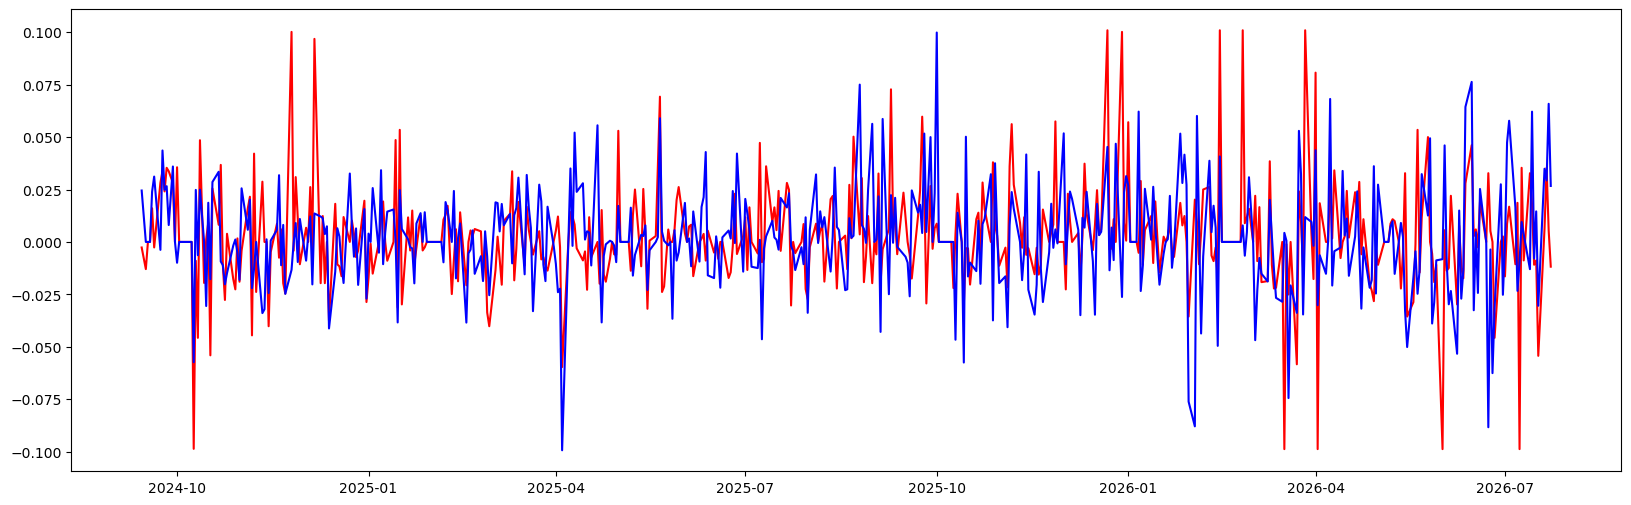

In [153]:
plt.figure(figsize=(20,6))
plt.plot(Y_test.index,y_pred,'r',label='Predicted')
plt.plot(Y_test.index,Y_test,'b',label='Actual')

在这里我搞错了,原项目是用百分比变化去看金价和因子之间的关系的.实际上预测并不是把每一个因素都用百分比来预测的.

---  
重新把原来的数据进行标准化

In [156]:
X

,A_500,Dollar Index,cn_10y_rate,us_10y_rate,brent,Copper Futures Price,Gold Futures Price
2012-05-09,1000.000000,80.080002,3.5414,1.87,111.89,3.6595,1000.000000
2012-05-10,1000.166229,80.110001,3.5287,1.89,112.24,3.6905,1000.878474
2012-05-11,993.645535,80.279999,3.4907,1.84,112.50,3.6480,993.662561
2012-05-14,986.340876,80.599998,3.4461,1.78,110.79,3.5540,979.230736
2012-05-15,986.907436,81.220001,3.4050,1.76,111.40,3.5175,976.846393
...,...,...,...,...,...,...,...
2026-07-17,2024.406692,100.750000,1.7404,4.55,85.01,6.2650,2517.851587
2026-07-20,2040.782832,100.989998,1.7453,4.60,86.99,6.3410,2516.345719
2026-07-21,2119.573044,101.180000,1.7450,4.63,93.85,6.5525,2554.495967
2026-07-22,2106.458340,101.139999,1.7297,4.67,94.12,6.4935,2602.058122


In [157]:
Y

2012-05-09     4.28
2012-05-10     4.26
2012-05-11     4.20
2012-05-14     4.15
2012-05-15     4.14
              ...  
2026-07-17    28.36
2026-07-20    29.35
2026-07-21    30.21
2026-07-22    32.20
2026-07-23    33.06
Name: Zijin, Length: 3837, dtype: float64

## 1 决策树

In [161]:
X = df_all.drop(columns=['Zijin'])
Y = df_all['Zijin']
X_train, X_test = X.iloc[:-500], X.iloc[-500:]
Y_train, Y_test = Y.iloc[:-500], Y.iloc[-500:]
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
dt.fit(X_train_scaled, Y_train)
y_pred = dt.predict(X_test_scaled)
RMSE = np.sqrt(mean_squared_error(Y_test, y_pred))
print(f"RMSE: {RMSE}")
R2 = r2_score(Y_test, y_pred)
print(f"R2: {R2}")

RMSE: 11.772556876057129
R2: -1.1499284400358252


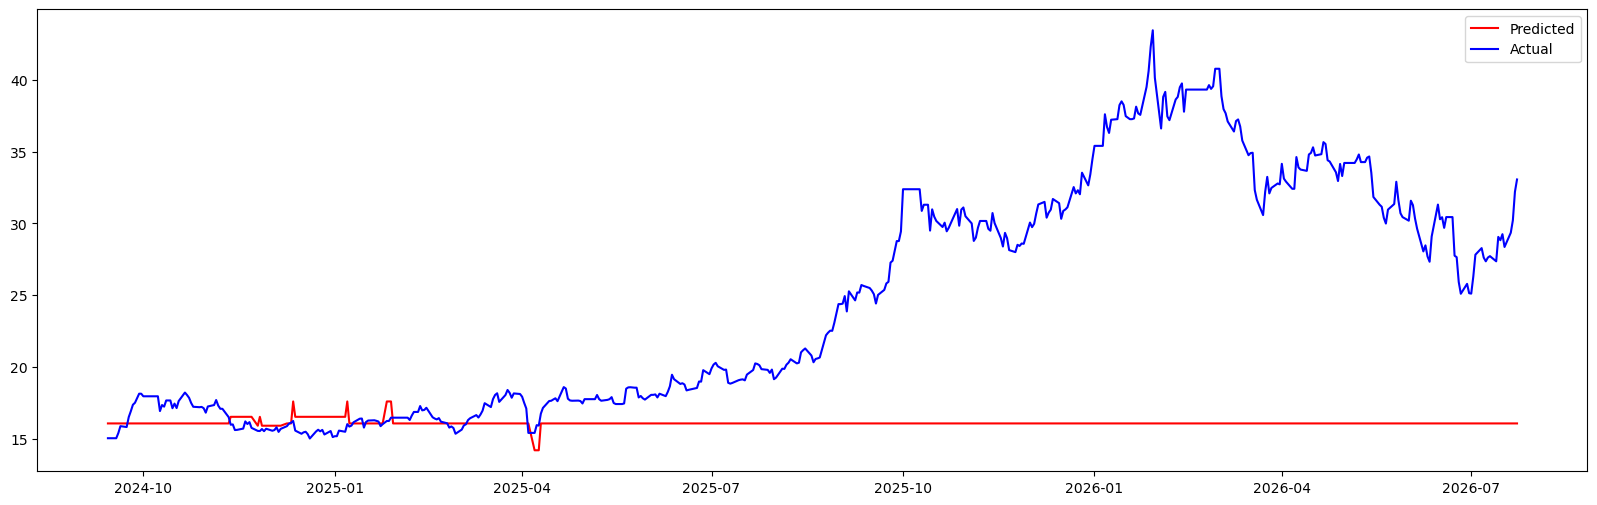

In [162]:
plt.figure(figsize=(20,6))
plt.plot(Y_test.index,y_pred,'r',label='Predicted')
plt.plot(Y_test.index,Y_test,'b',label='Actual')
plt.legend()
plt.show()

为什么会出现这样的情况?Decision Tree Regressor 为什么回归的结果近乎是平的?

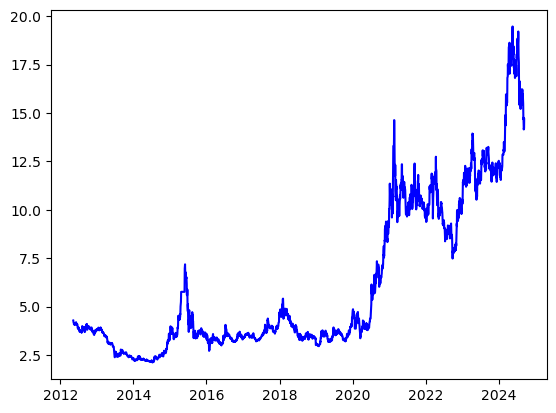

In [163]:
plt.plot(Y_train.index,Y_train,'b',label='Actual')

In [164]:
np.unique(y_pred)

array([14.2 , 15.91, 16.07, 16.53, 17.6 ])

由于决策树的性质,他是根据指数,金价,铜价等等归类的,然后取平均值.对于一些元素的变化,24年以后大幅波动无法预测,也无法外推,因此造成预测全为直线的现象.  
比如,股价Y只经历了最高20元的时期,所以我们无法获得后续的归纳推理取平均值.  
针对这个判断,我们找中间一段时间.

In [165]:
X = df_all.drop(columns=['Zijin'])
Y = df_all['Zijin']
X_train, X_test = X.iloc[0:1500], X.iloc[1500:1800]
Y_train, Y_test = Y.iloc[0:1500], Y.iloc[1500:1800]
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
dt.fit(X_train_scaled, Y_train)
y_pred = dt.predict(X_test_scaled)
RMSE = np.sqrt(mean_squared_error(Y_test, y_pred))
print(f"RMSE: {RMSE}")
R2 = r2_score(Y_test, y_pred)
print(f"R2: {R2}")

RMSE: 0.39925013045291124
R2: 0.5140129590107826


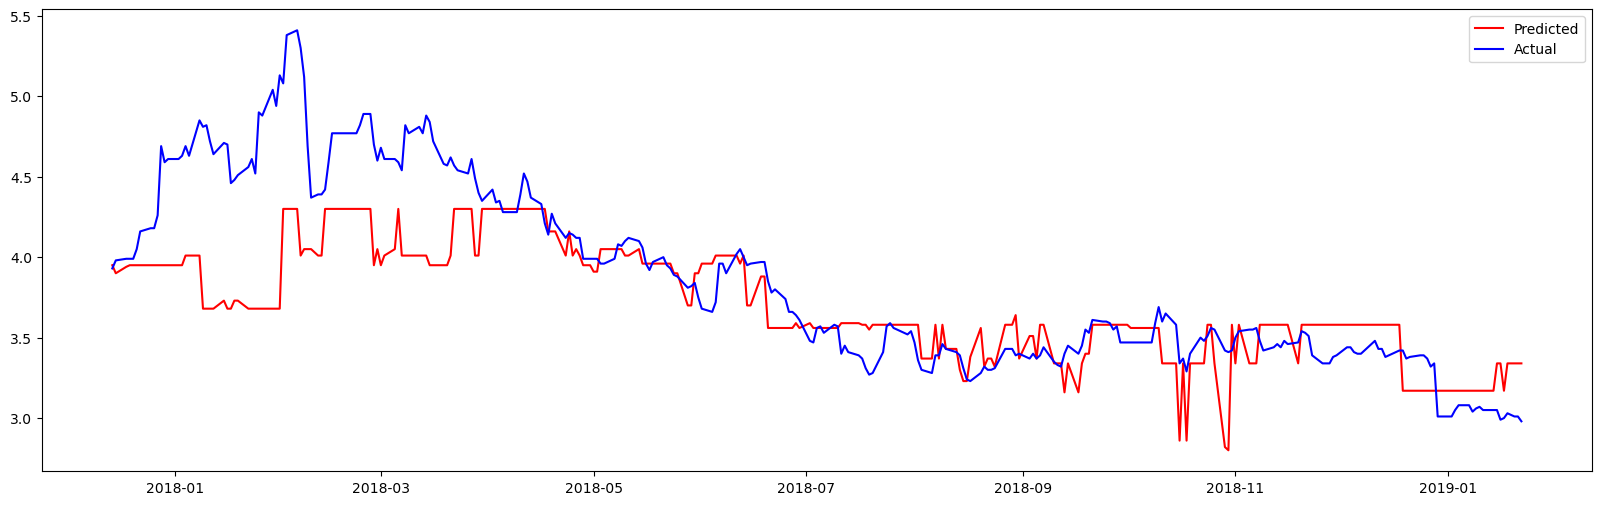

In [166]:
plt.figure(figsize=(20,6))
plt.plot(Y_test.index,y_pred,'r',label='Predicted')
plt.plot(Y_test.index,Y_test,'b',label='Actual')
plt.legend()
plt.show()

In [167]:
np.unique(y_pred)

array([2.8 , 2.82, 2.86, 3.16, 3.17, 3.23, 3.3 , 3.32, 3.34, 3.37, 3.38,
       3.4 , 3.43, 3.51, 3.55, 3.56, 3.58, 3.59, 3.64, 3.68, 3.7 , 3.73,
       3.88, 3.9 , 3.91, 3.94, 3.95, 3.96, 4.01, 4.05, 4.16, 4.3 ])

有明显的改善,但是X的情况我们没有实际分开确认过.后面的叫平稳的时间段预测相对准确.但是回归树也只是归纳出几种情况,在因子剧烈变化的时候,由于缺乏以前的经验,因此无法进行预测.  

回归树的性质是-- **预测结果不会超过训练集的范围**

因此,针对一个成长型的股票,我们放弃回归树.

## 2 SVR

In [172]:
from sklearn.svm import SVR
svr_lin = SVR(kernel='linear')

In [174]:
X_train, X_test = X.iloc[:-500], X.iloc[-500:]
Y_train, Y_test = Y.iloc[:-500], Y.iloc[-500:]
linear_svr_clf_feat = svr_lin.fit(X_train,Y_train)

In [175]:
X = df_all.drop(columns=['Zijin'])
Y = df_all['Zijin']
X_train, X_test = X.iloc[:-500], X.iloc[-500:]
Y_train, Y_test = Y.iloc[:-500], Y.iloc[-500:]
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
linear_svr_clf_feat.fit(X_train_scaled, Y_train)
y_pred = linear_svr_clf_feat.predict(X_test_scaled)
RMSE = np.sqrt(mean_squared_error(Y_test, y_pred))
print(f"RMSE: {RMSE}")
R2 = r2_score(Y_test, y_pred)
print(f"R2: {R2}")

RMSE: 3.949841530740804
R2: 0.7579852955007451


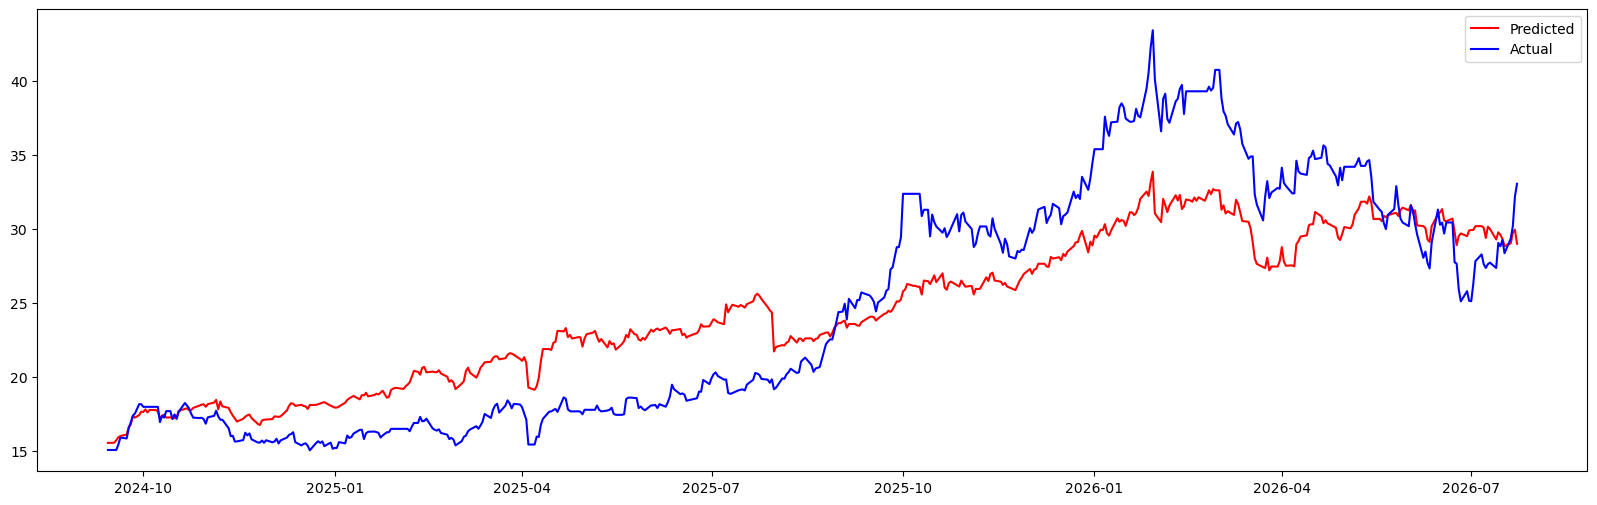

In [176]:
plt.figure(figsize=(20,6))
plt.plot(Y_test.index,y_pred,'r',label='Predicted')
plt.plot(Y_test.index,Y_test,'b',label='Actual')
plt.legend()
plt.show()

SVR类似于多元回归,只是会惩罚偏差较大的数字.因此可以线性外推.  
从趋势上来看是一致的,但是结合2026年1月的波峰和下跌,我认为是还有一些技术性或者是群体共识的心态在里面,因此模型没有将其考虑在内.因为我只考虑了指数和宏观因子,商品价格在内的趋势.  
紫金价格 =  
+ 中国股市环境
+ 黄金周期
+ 铜周期
+ 全球商品周期
+ 美元
+ 中美国债利率

LinearSVR可以让一定程度的范围偏差可以忍受,找一个总体稳定,不要过度收少数点影响的关系.而OLS是让整体平方差最小,受极端值影响较大.  

SVR的其他内核模型可以构建非线性关系,值得考虑.

### LinearSVR调参

In [178]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

经过之前的最佳参数,在附近减少C和epsilon的分布范围.

In [189]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='linear'))
])

parameters = {
    'svr__C': [0.5, 1.0,5.0 ,10.0, 20.0,30.0],
    'svr__epsilon': [0.1, 0.5, 1.0, 3.0],
}

ts_split = TimeSeriesSplit(n_splits=5)


grid = GridSearchCV(
    estimator=pipe,
    param_grid=parameters,
    cv=ts_split,
    scoring='neg_root_mean_squared_error',
    refit=True
)

grid.fit(X_train, Y_train)

print("最佳参数：", grid.best_params_)
print("交叉验证最佳RMSE：", -grid.best_score_)

Y_pred = grid.predict(X_test)


rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
r2 = r2_score(Y_test, Y_pred)

print("最终测试集 RMSE：", rmse)
print("最终测试集 R²：", r2)


最佳参数： {'svr__C': 1.0, 'svr__epsilon': 0.5}
交叉验证最佳RMSE： 1.8975702487454775
最终测试集 RMSE： 3.71177467692725
最终测试集 R²： 0.7862797767387097


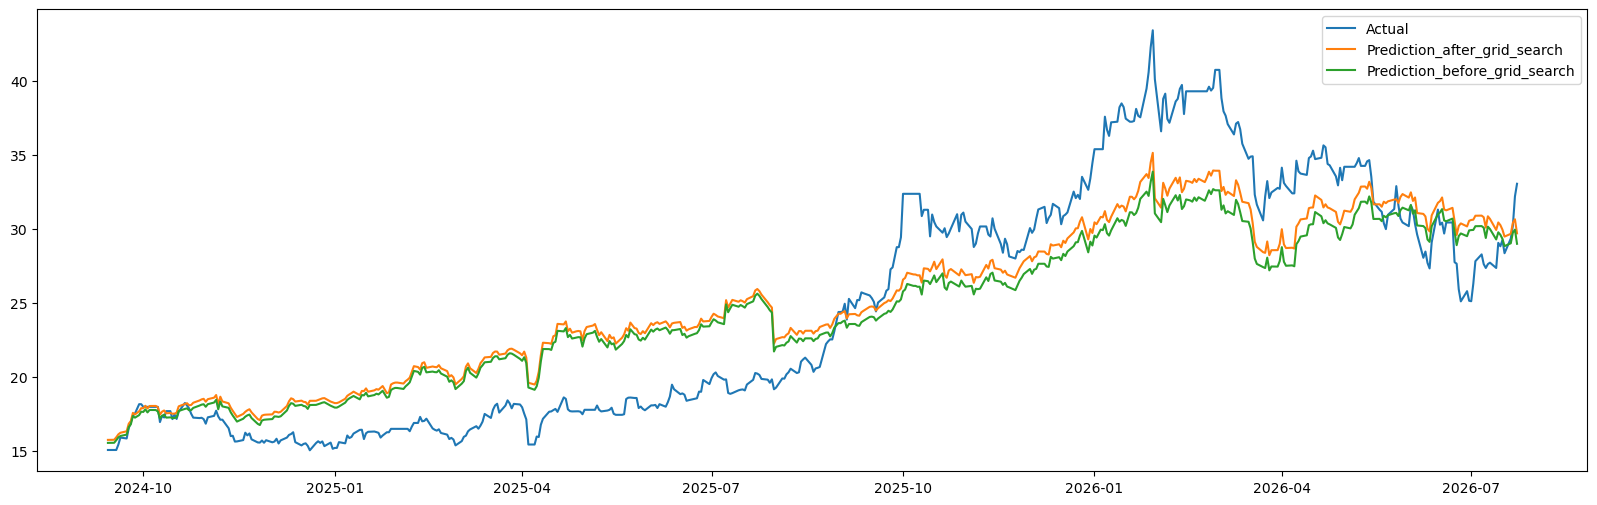

In [190]:
plt.figure(figsize=(20,6))
plt.plot(Y_test.index, Y_test, label='Actual')
plt.plot(Y_test.index, Y_pred, label='Prediction_after_grid_search')
plt.plot(Y_test.index, y_pred, label='Prediction_before_grid_search')
plt.legend()
plt.show()

经过两次参数调优,测试的结果略有改善.但是24-26年间的大行情有特殊性.巨大的涨跌幅现有的模型可能仍然无法解释.  
通过系数看出最佳的C为1,epsilon为0.5,也就是说我们让曲线更加平滑一点,泛化能力更强,在测试集里表现可能更好.惩罚能力不应该动.

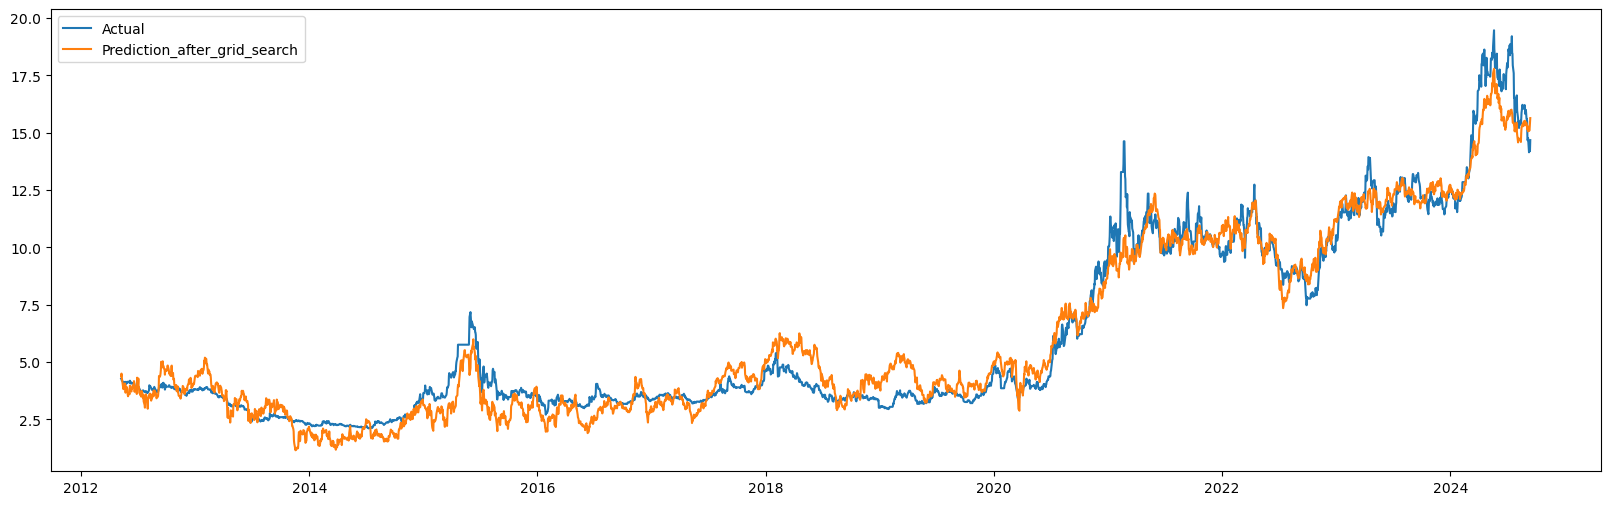

回测训练集 RMSE： 0.8001313468973337
回测训练集 R²： 0.9612389634102128


In [193]:
Y_pred = grid.predict(X_train)


rmse = np.sqrt(mean_squared_error(Y_train, Y_pred))
r2 = r2_score(Y_train, Y_pred)
plt.figure(figsize=(20,6))

plt.plot(Y_train.index, Y_train, label='Actual')
plt.plot(Y_train.index, Y_pred, label='Prediction_after_grid_search')
plt.legend()
plt.show()

print("回测训练集 RMSE：", rmse)
print("回测训练集 R²：", r2)

由于2024年前的紫金矿业并不太热门,且黄金的价格并没有那么极端,因此这个时候的预测准确性更好一点.

## 3 随机森林

In [200]:
from sklearn.ensemble import RandomForestRegressor

In [201]:
rf = RandomForestRegressor(random_state=0, n_estimators=100, max_depth=8,min_samples_split=2,min_samples_leaf=1,n_jobs=-1)
rf_model = rf.fit(X_train, Y_train)
y_pred = rf_model.predict(X_test)
RMSE = np.sqrt(mean_squared_error(Y_test, y_pred))
print(f"RMSE: {RMSE}")
R2 = r2_score(Y_test, y_pred)
print(f"R2: {R2}")

RMSE: 10.553929962093067
R2: -0.7278690508150591


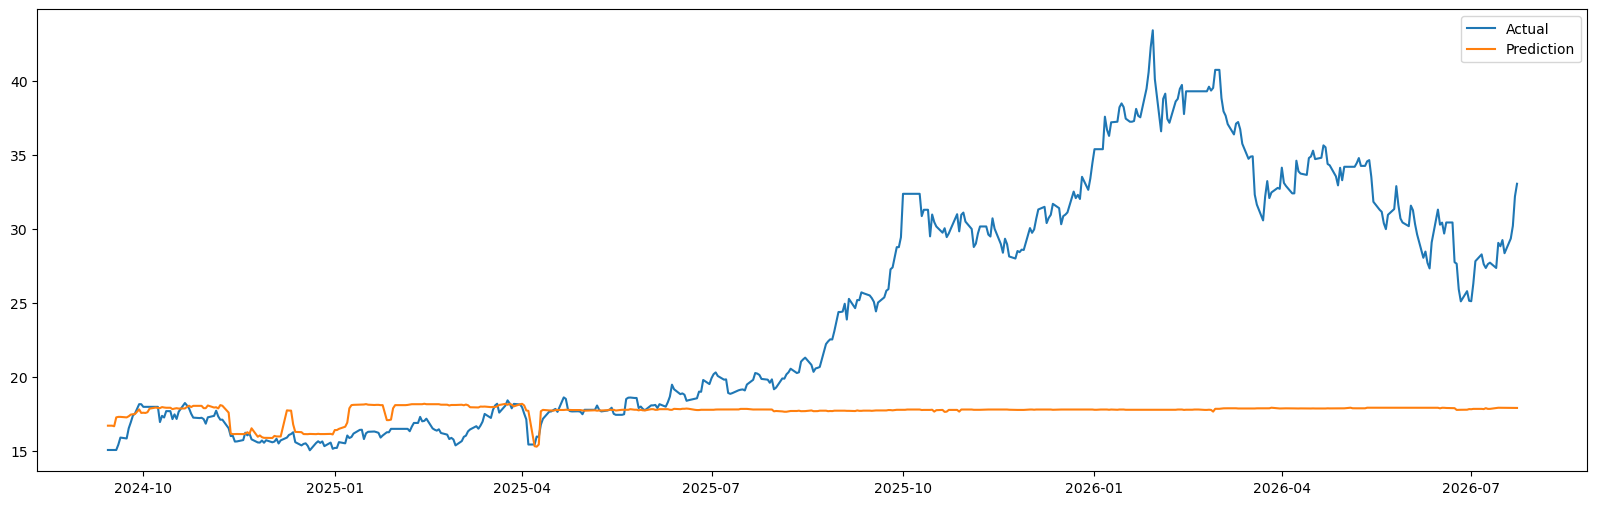

In [202]:
plt.figure(figsize=(20,6))
plt.plot(Y_test.index, Y_test, label='Actual')
plt.plot(Y_test.index, y_pred, label='Prediction')
plt.legend()
plt.show()

In [206]:
np.unique(y_pred).shape[0]

211

随机森林与决策树的问题一样,对于没有见过的情况无法判断.因此也会出现直线的现象.就没必要调参数试了.  
随机森林最核心的作用就是将多个决策树的值取平均,降低单棵树的不稳定和过拟合.

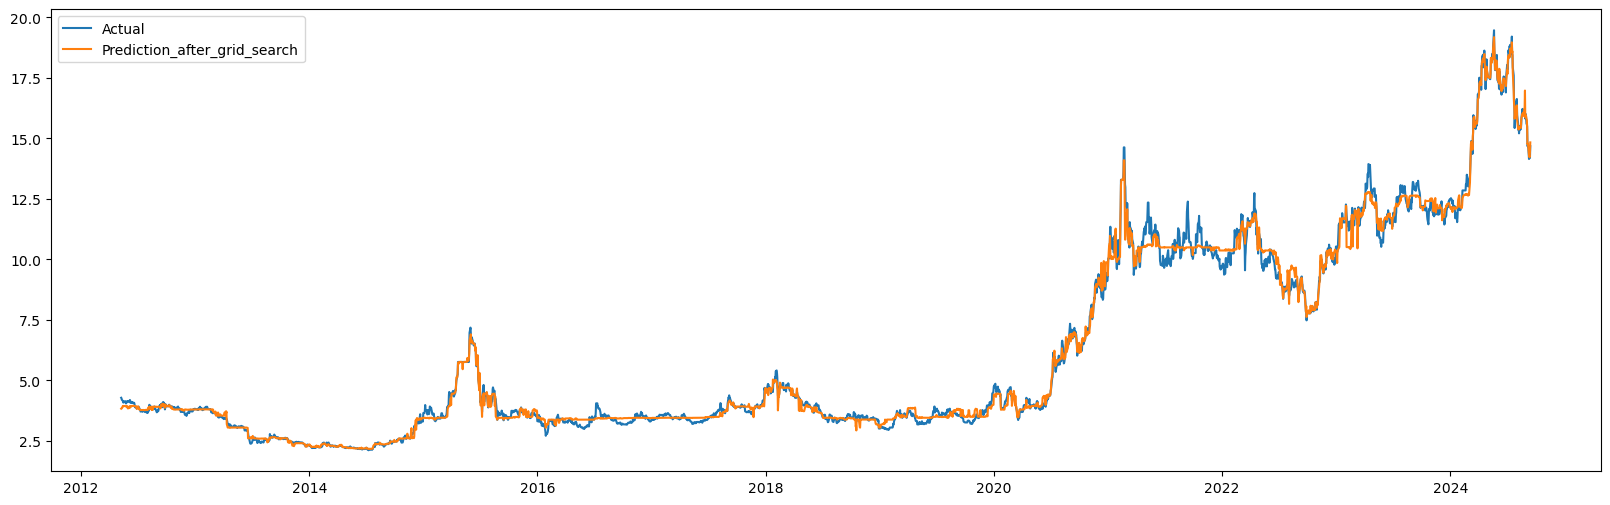

回测训练集 RMSE： 0.2734632567545233
回测训练集 R²： 0.9954723715957466


In [207]:
Y_pred = rf_model.predict(X_train)


rmse = np.sqrt(mean_squared_error(Y_train, Y_pred))
r2 = r2_score(Y_train, Y_pred)
plt.figure(figsize=(20,6))

plt.plot(Y_train.index, Y_train, label='Actual')
plt.plot(Y_train.index, Y_pred, label='Prediction_after_grid_search')
plt.legend()
plt.show()

print("回测训练集 RMSE：", rmse)
print("回测训练集 R²：", r2)

与决策树的效果一样,对于已知的情况效果很好,但是对于未知的情况无法外推.

## 4 Lasso 和 Ridge 模型

Ridge模型更适合于有一大堆变量,不知道哪些起作用,哪些有多重共线性,力求让整体系数偏小的模型.通常**保留所有特征**  
Lasso也是,但是他会把一些系数降低为0,删去一些没用的变量.起到**筛选特征**的作用.  
但是原项目,是把一大堆数据作为特征,但是我的模型中只有7个变量,在开始之前,我认为Lasso不会有太大的差别.我会重点观察系数,看看哪一些系数比较重要.


也许之后新添加因子,可以用Lasso找出没有用的变量.

In [280]:
def test_model(model):
    model.fit(X_train, Y_train)
    Y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
    r2 = r2_score(Y_test, Y_pred)



    print("测试集 RMSE：", rmse)
    print("测试集 R²：", r2)
    
    plt.figure(figsize=(20,6))
    plt.plot(Y_test.index, Y_test, label='Actual')
    plt.plot(Y_test.index, Y_pred, label='Prediction')
    plt.legend()
    plt.show()


In [250]:
from sklearn.linear_model import Lasso

回测训练集 RMSE： 2.3446136380437923
回测训练集 R²： 0.9147243607217701


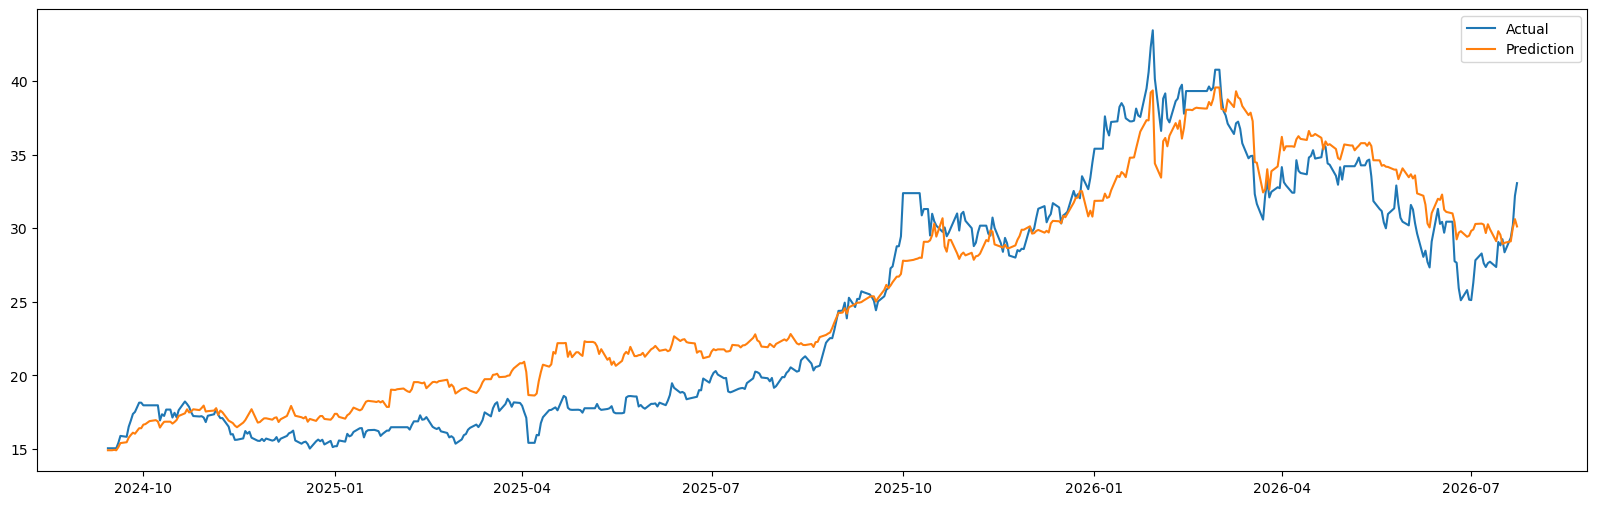

In [257]:
lasso = LassoCV(
    alphas = 1000,
    cv=ts_split,
    max_iter=10000
    )
test_model(lasso)

相比于LinearSVG表现明显更好,波动减小了更多,这是为什么?是不是我在构建了7个变量中,有的根本不重要?  
SVR天然会对波动更加宽容,不Lasso对预测错误惩罚更加基金.因此SVR跟上了大方向,但是对于突变则跟踪不好.  
SVR的惩罚是根据线性的,Lasso与OLS一样是根据平方差的.

In [258]:
pd.Series(lasso.coef_, index=X_train.columns)

A_500                   0.002744
Dollar Index            0.104663
cn_10y_rate            -0.000000
us_10y_rate             0.000000
brent                   0.025895
Copper Futures Price    0.000000
Gold Futures Price      0.013182
dtype: float64

In [245]:
X_train.head()

,A_500,Dollar Index,cn_10y_rate,us_10y_rate,brent,Copper Futures Price,Gold Futures Price
2012-05-09,1000.000000,80.080002,3.5414,1.87,111.89,3.6595,1000.000000
2012-05-10,1000.166229,80.110001,3.5287,1.89,112.24,3.6905,1000.878474
2012-05-11,993.645535,80.279999,3.4907,1.84,112.50,3.6480,993.662561
2012-05-14,986.340876,80.599998,3.4461,1.78,110.79,3.5540,979.230736
2012-05-15,986.907436,81.220001,3.4050,1.76,111.40,3.5175,976.846393


我这次处理的时候,没有加上正则化,是否由于单位大小不一致,导致模型把铜,美债与国债收益率给完全忽视了呢?

回测训练集 RMSE： 3.6790546524182774
回测训练集 R²： 0.7900311407183033


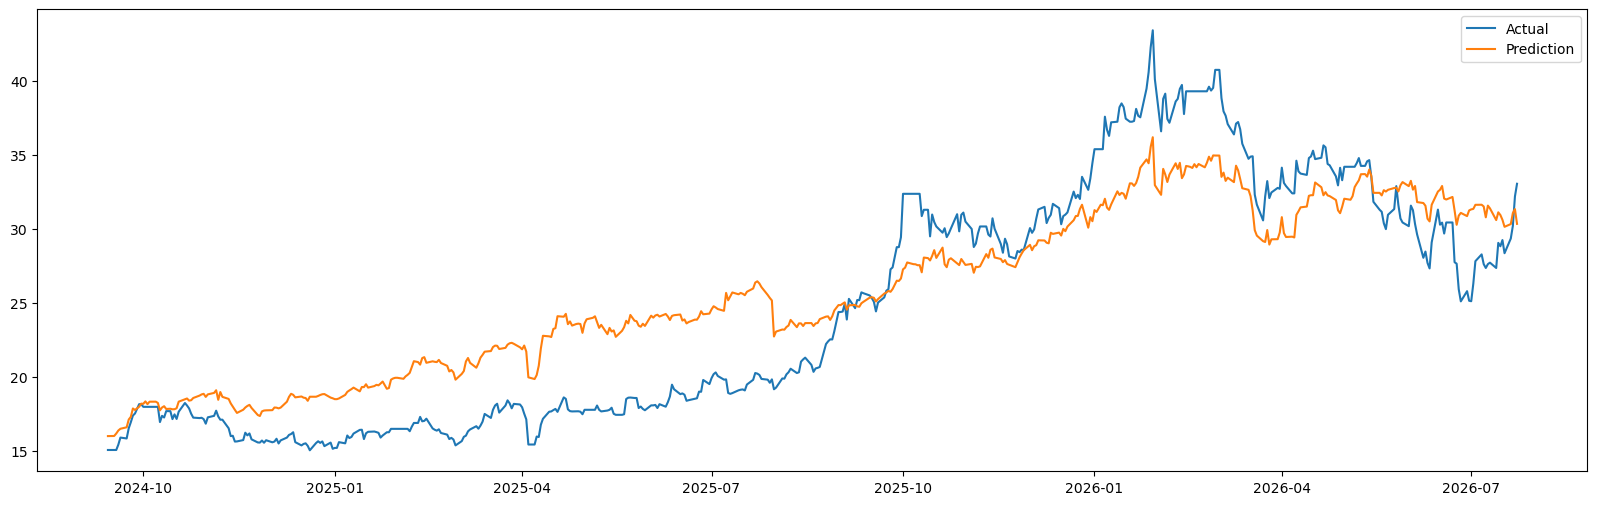

In [263]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000))
])

ts_split = TimeSeriesSplit(n_splits=5)

parameters = {
    'lasso__alpha': np.logspace(-5, 1, 1000)
}

grid_lasso = GridSearchCV(
    estimator=pipe,
    param_grid=parameters,
    cv=ts_split,
    scoring='neg_root_mean_squared_error',
    refit=True
)

grid_lasso.fit(X_train, Y_train)

Y_pred = grid_lasso.predict(X_test)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
r2 = r2_score(Y_test, Y_pred)

print("回测训练集 RMSE：", rmse)
print("回测训练集 R²：", r2)
plt.figure(figsize=(20,6))
plt.plot(Y_test.index, Y_test, label='Actual')
plt.plot(Y_test.index, Y_pred, label='Prediction')
plt.legend()
plt.show()


In [264]:
pd.Series(grid_lasso.best_estimator_.named_steps['lasso'].coef_, index=X_train.columns)

A_500                   1.222544
Dollar Index           -0.850161
cn_10y_rate            -1.077523
us_10y_rate             1.693202
brent                  -0.729049
Copper Futures Price    1.317127
Gold Futures Price      1.398461
dtype: float64

仍然表现不好,仅有少量的提升.加了标准化后,所有的数据都有了权重.

查看一下LassoCV的alpha,看看是否是权重设置的有问题.

In [269]:
lasso.alpha_

np.float64(0.8492160948223609)

In [270]:
lasso.alphas_

array([849.21609482, 843.36430074, 837.55283031, 831.78140567,
       826.04975086, 820.35759186, 814.70465648, 809.09067446,
       803.51537737, 797.97849864, 792.47977354, 787.01893916,
       781.5957344 , 776.20989995, 770.86117832, 765.54931375,
       760.27405228, 755.03514168, 749.83233147, 744.66537287,
       739.53401885, 734.43802406, 729.37714484, 724.35113923,
       719.35976691, 714.40278923, 709.47996918, 704.5910714 ,
       699.73586212, 694.91410921, 690.12558212, 685.37005191,
       680.64729119, 675.95707416, 671.29917656, 666.67337569,
       662.07945038, 657.51718097, 652.98634933, 648.48673883,
       644.01813434, 639.58032218, 635.17309019, 630.79622763,
       626.44952523, 622.13277518, 617.84577106, 613.58830791,
       609.36018217, 605.16119168, 600.99113567, 596.84981476,
       592.73703094, 588.65258757, 584.59628935, 580.56794235,
       576.56735396, 572.5943329 , 568.64868921, 564.73023423,
       560.83878061, 556.9741423 , 553.13613451, 549.32

In [274]:
grid_lasso.best_params_

{'lasso__alpha': np.float64(1e-05)}

由于这个正好在边缘,是否我们的alpha值取得太大了?重新调整一下模型.

回测训练集 RMSE： 3.67913730488492
回测训练集 R²： 0.7900217064256836


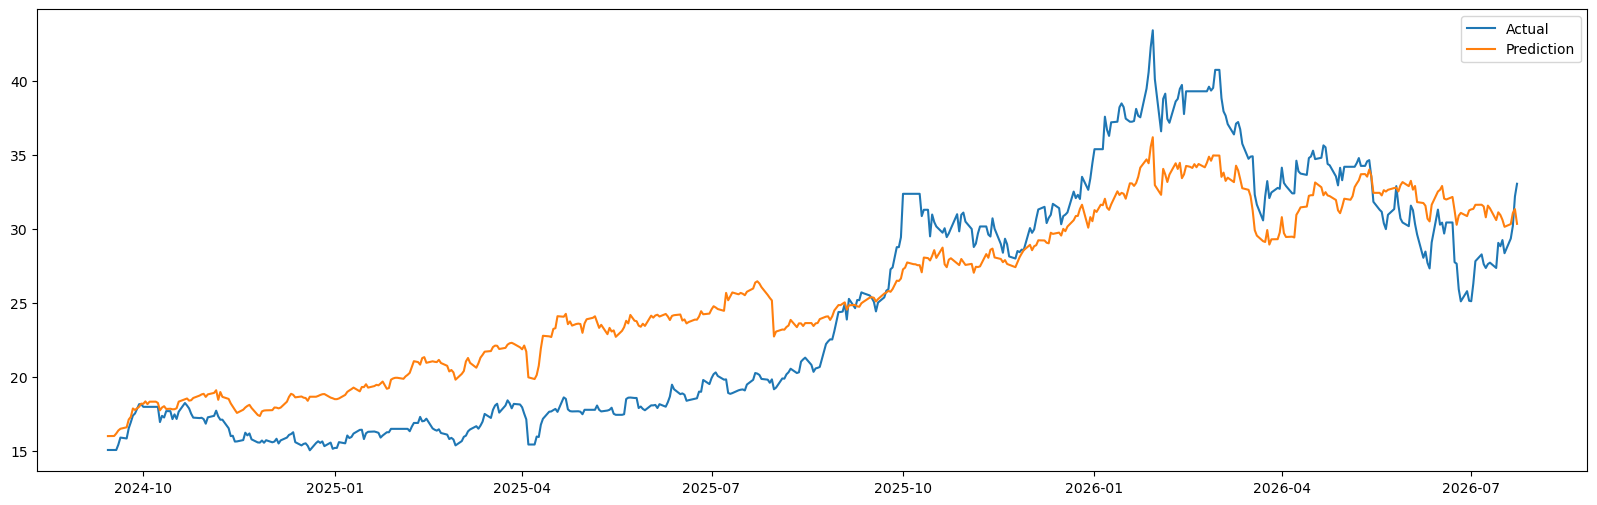

In [275]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000))
])

ts_split = TimeSeriesSplit(n_splits=5)

parameters = {
    'lasso__alpha': np.logspace(-8, -5, 1000) ##调整一下范围
}

grid_lasso = GridSearchCV(
    estimator=pipe,
    param_grid=parameters,
    cv=ts_split,
    scoring='neg_root_mean_squared_error',
    refit=True
)

grid_lasso.fit(X_train, Y_train)

Y_pred = grid_lasso.predict(X_test)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
r2 = r2_score(Y_test, Y_pred)

print("回测训练集 RMSE：", rmse)
print("回测训练集 R²：", r2)
plt.figure(figsize=(20,6))
plt.plot(Y_test.index, Y_test, label='Actual')
plt.plot(Y_test.index, Y_pred, label='Prediction')
plt.legend()
plt.show()


In [276]:
grid_lasso.best_params_

{'lasso__alpha': np.float64(1e-08)}

仍然贴边,继续调整范围

In [279]:
grid_lasso.best_params_

{'lasso__alpha': np.float64(1e-10)}

似乎已经没有意义了,正则化下,进行惩罚的权重太小,无限接近于0,没有性能上的差别了.这样的话无法给予真正的惩罚.

回测训练集 RMSE： 3.679137386771991
回测训练集 R²： 0.7900216970786512


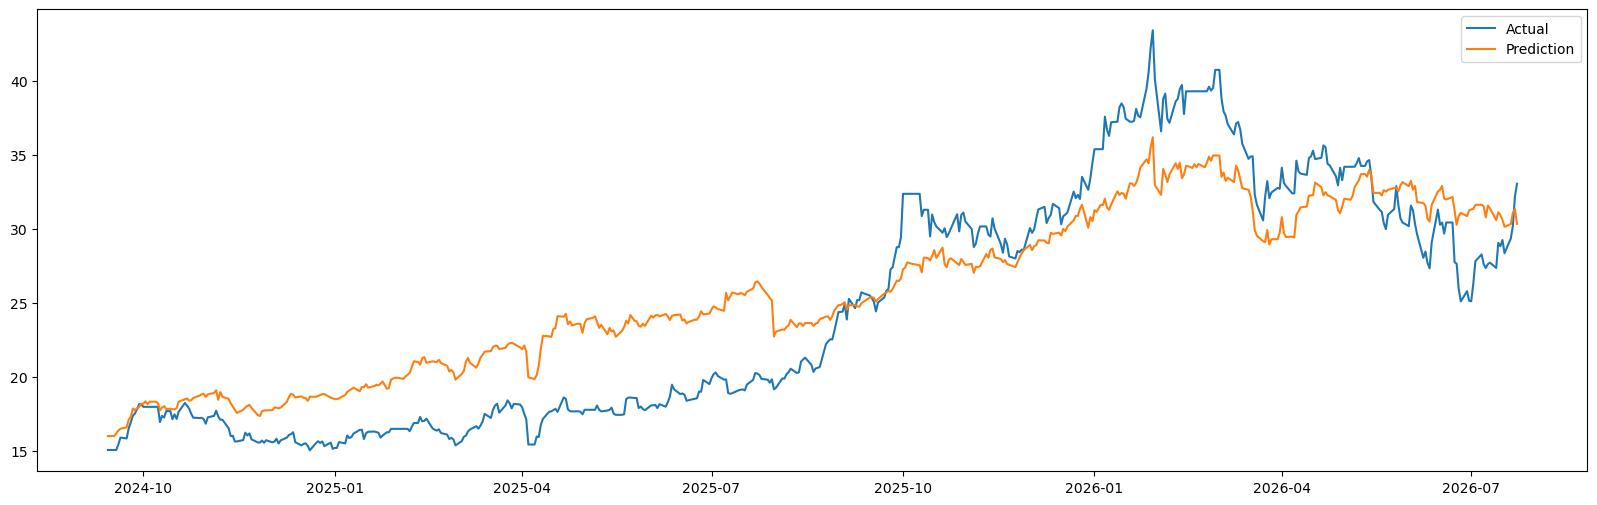

In [ ]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=1000))
])

ts_split = TimeSeriesSplit(n_splits=5)

parameters = {
    'lasso__alpha': np.logspace(-10, -8, 1000) ##调整一下范围
}

grid_lasso = GridSearchCV(
    estimator=pipe,
    param_grid=parameters,
    cv=ts_split,
    scoring='neg_root_mean_squared_error',
    refit=True
)

grid_lasso.fit(X_train, Y_train)

Y_pred = grid_lasso.predict(X_test)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
r2 = r2_score(Y_test, Y_pred)

print("回测训练集 RMSE：", rmse)
print("回测训练集 R²：", r2)
plt.figure(figsize=(20,6))
plt.plot(Y_test.index, Y_test, label='Actual')
plt.plot(Y_test.index, Y_pred, label='Prediction')
plt.legend()
plt.show()


测试集 RMSE： 3.650923458613899
测试集 R²： 0.7932298388053324


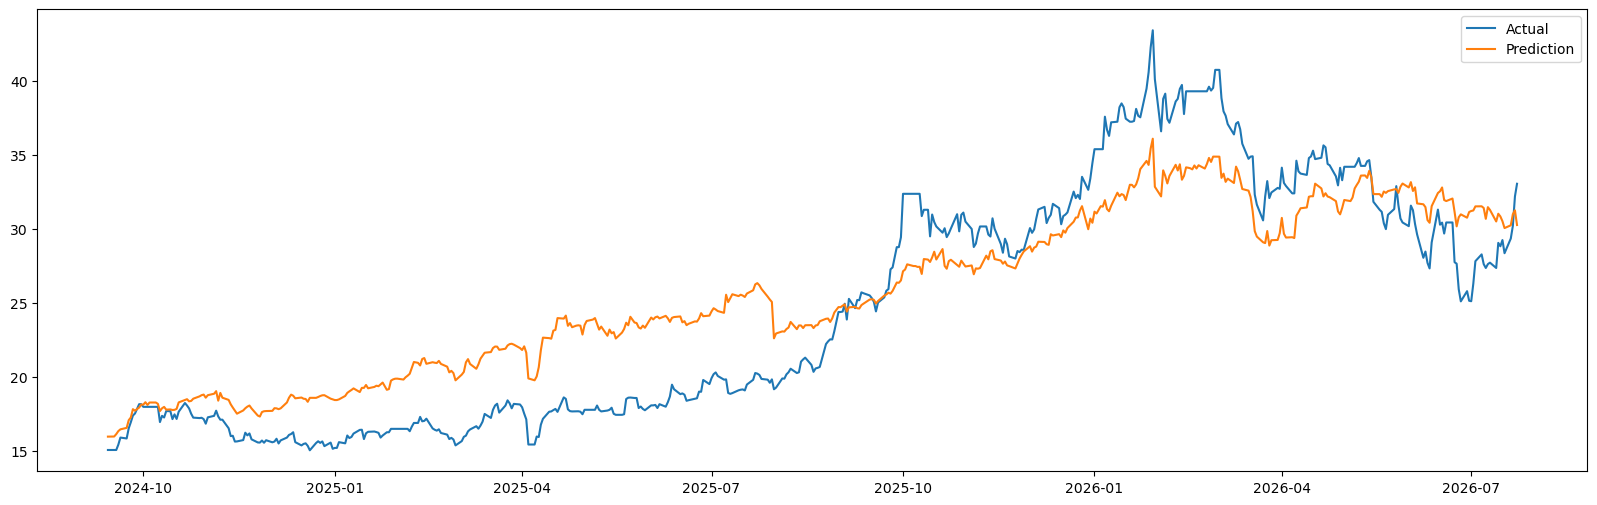

In [282]:
lasso = LassoCV(
    alphas = 1000,
    cv=ts_split,
    max_iter=10000
    )


lasso.fit(X_train_scaled, Y_train)
Y_pred = lasso.predict(X_test_scaled)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
r2 = r2_score(Y_test, Y_pred)



print("测试集 RMSE：", rmse)
print("测试集 R²：", r2)
    
plt.figure(figsize=(20,6))
plt.plot(Y_test.index, Y_test, label='Actual')
plt.plot(Y_test.index, Y_pred, label='Prediction')
plt.legend()
plt.show()


In [285]:
display(X_train_scaled)

array([[-1.321422  , -1.80805084,  0.60162853, ...,  1.54661538,
         0.62518298,  0.16103387],
       [-1.32097387, -1.80427546,  0.57730935, ...,  1.56104151,
         0.66997651,  0.16527594],
       [-1.33855299, -1.78288101,  0.5045433 , ...,  1.57175806,
         0.60856602,  0.13043094],
       ...,
       [-0.38799562,  0.91033207, -2.15007701, ..., -0.16720871,
         1.29058375,  2.94378627],
       [-0.40518923,  0.87131855, -2.15888553, ..., -0.02294742,
         1.36572129,  3.06225882],
       [-0.42531334,  0.838597  , -2.21135368, ..., -0.0283057 ,
         1.42496436,  3.15346212]], shape=(3337, 7))

In [286]:
pd.Series(lasso.coef_, index=X_train.columns)

A_500                   1.189356
Dollar Index           -0.774392
cn_10y_rate            -1.035866
us_10y_rate             1.647750
brent                  -0.712930
Copper Futures Price    1.330970
Gold Futures Price      1.406203
dtype: float64

效果也没什么区别,本来未正则化的值表现反而更好.如果把正则化后的值,删去债券和铜的影响会怎么样?看看是否正巧最近两年的数据正好符合系数为0的情况.

In [299]:
X_train_scaled_temp = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_train_scaled_temp[['cn_10y_rate','us_10y_rate','Copper Futures Price']] = 0 
display(X_train_scaled_temp)

,A_500,Dollar Index,cn_10y_rate,us_10y_rate,brent,Copper Futures Price,Gold Futures Price
0,-1.321422,-1.808051,0,0,1.546615,0,0.161034
1,-1.320974,-1.804275,0,0,1.561042,0,0.165276
2,-1.338553,-1.782881,0,0,1.571758,0,0.130431
3,-1.358246,-1.742609,0,0,1.501276,0,0.060741
4,-1.356718,-1.664581,0,0,1.526419,0,0.049227
...,...,...,...,...,...,...,...
3332,-0.390753,0.893972,0,0,-0.082301,0,2.912577
3333,-0.386317,0.904039,0,0,-0.165972,0,2.944392
3334,-0.387996,0.910332,0,0,-0.167209,0,2.943786
3335,-0.405189,0.871319,0,0,-0.022947,0,3.062259


In [297]:
X_test_scaled_temp = pd.DataFrame(X_test_scaled, columns=X_test.columns)
X_test_scaled_temp[['cn_10y_rate','us_10y_rate','Copper Futures Price']] = 0 
display(X_test_scaled_temp)

,A_500,Dollar Index,cn_10y_rate,us_10y_rate,brent,Copper Futures Price,Gold Futures Price
0,-0.411652,0.794549,0,0,-0.016765,0,3.121344
1,-0.411652,0.794549,0,0,-0.016765,0,3.121344
2,-0.411652,0.810910,0,0,0.007554,0,3.121344
3,-0.411652,0.774413,0,0,0.006317,0,3.121344
4,-0.380954,0.775671,0,0,0.064434,0,3.173763
...,...,...,...,...,...,...,...
495,1.440273,0.793291,0,0,0.438689,0,7.490604
496,1.484422,0.823495,0,0,0.520299,0,7.483332
497,1.696832,0.847407,0,0,0.803051,0,7.667556
498,1.661476,0.842372,0,0,0.814180,0,7.897230


测试集 RMSE： 2.3321353093725095
测试集 R²： 0.9156296406426093


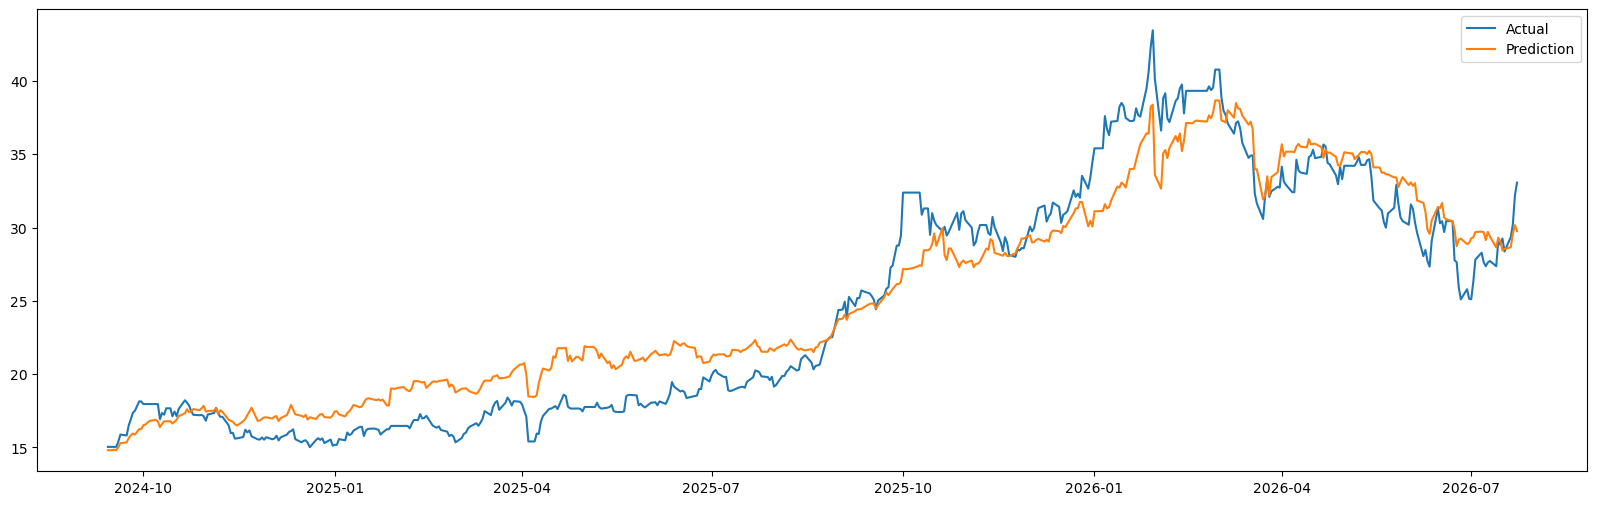

In [300]:
lasso = LassoCV(
    alphas = 1000,
    cv=ts_split,
    max_iter=10000
    )


lasso.fit(X_train_scaled_temp, Y_train)
Y_pred = lasso.predict(X_test_scaled_temp)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
r2 = r2_score(Y_test, Y_pred)



print("测试集 RMSE：", rmse)
print("测试集 R²：", r2)
    
plt.figure(figsize=(20,6))
plt.plot(Y_test.index, Y_test, label='Actual')
plt.plot(Y_test.index, Y_pred, label='Prediction')
plt.legend()
plt.show()


In [303]:
pd.Series(lasso.coef_, index=X_train.columns)

A_500                   0.985742
Dollar Index            1.026972
cn_10y_rate             0.000000
us_10y_rate             0.000000
brent                   0.743838
Copper Futures Price    0.000000
Gold Futures Price      2.646411
dtype: float64

忽视了铜价表现和利率表现,结果反而更好.经过标准化后,我们看出黄金价格走势对紫金矿业影响最大.

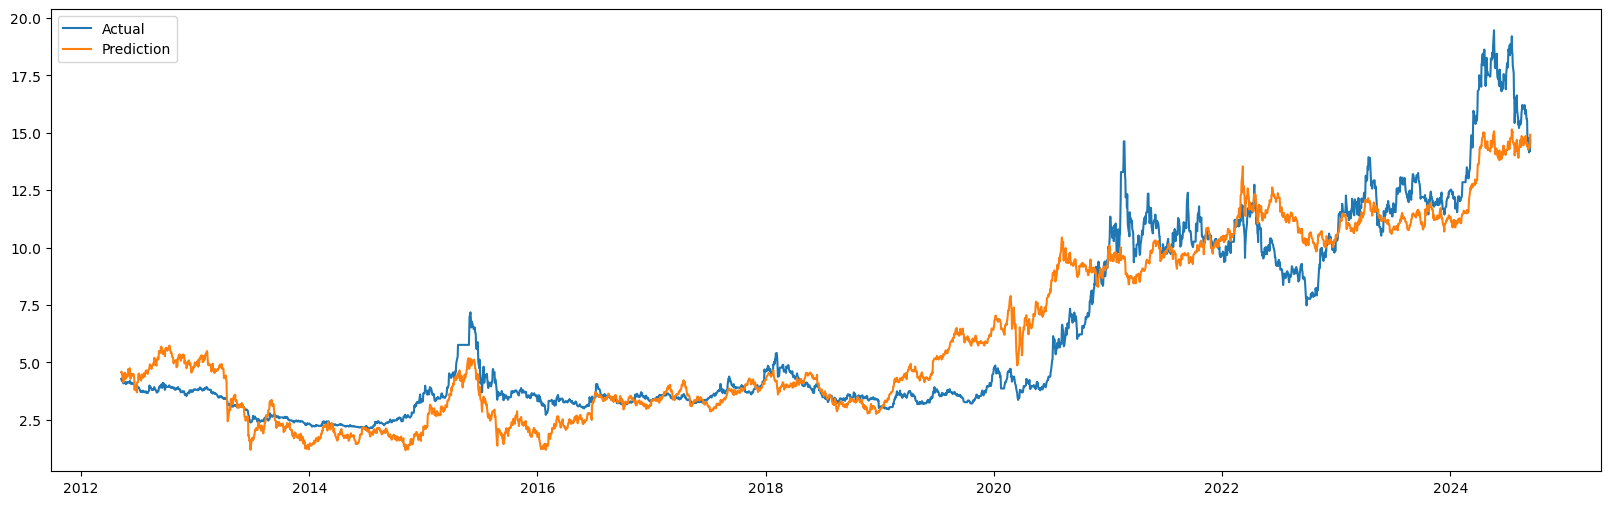

训练集 RMSE： 1.4383076155280252
训练集 R²： 0.874750392821934


In [309]:
Y_pred = lasso.predict(X_train_scaled_temp)
plt.figure(figsize=(20,6))
plt.plot(Y_train.index, Y_train, label='Actual')
plt.plot(Y_train.index, Y_pred, label='Prediction')
plt.legend()
plt.show()
rmse = np.sqrt(mean_squared_error(Y_train, Y_pred))
r2 = r2_score(Y_train, Y_pred)
print("训练集 RMSE：", rmse)
print("训练集 R²：", r2)


回测训练集 RMSE： 0.7958627013640581
回测训练集 R²： 0.9616514351254349


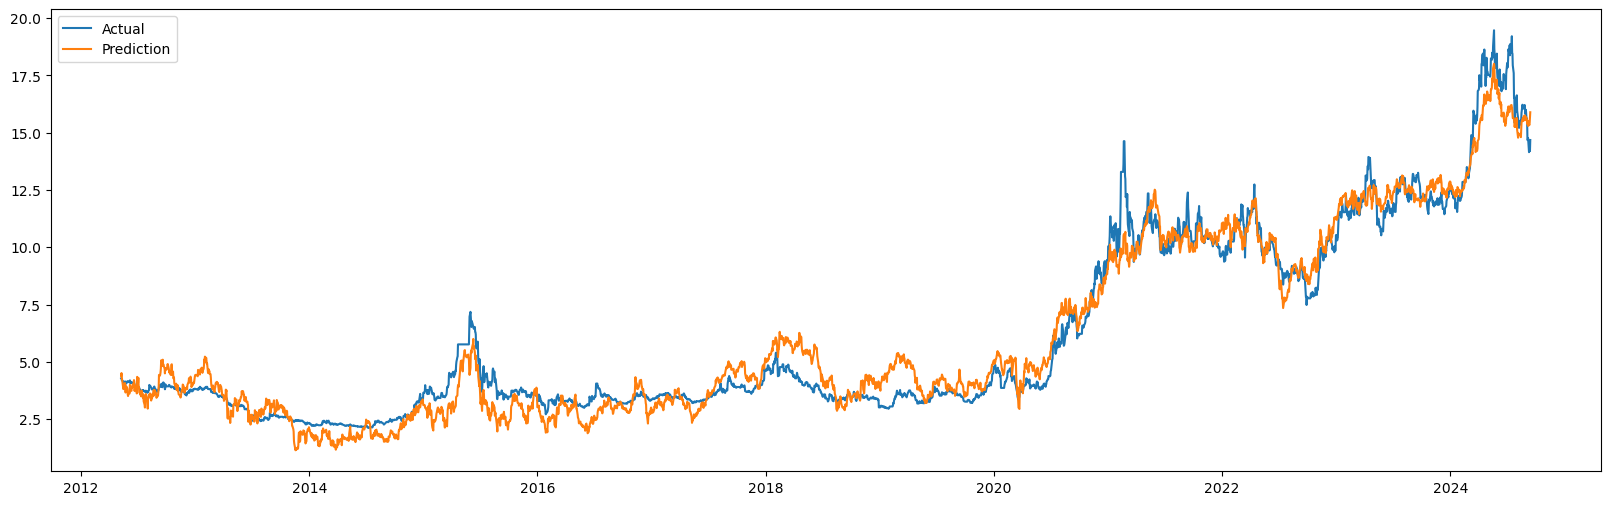

In [308]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=1000))
])

ts_split = TimeSeriesSplit(n_splits=5)

parameters = {
    'lasso__alpha': np.logspace(-3, 1, 1000) ##调整一下范围
}

grid_lasso = GridSearchCV(
    estimator=pipe,
    param_grid=parameters,
    cv=ts_split,
    scoring='neg_root_mean_squared_error',
    refit=True
)

grid_lasso.fit(X_train_scaled , Y_train)

Y_pred = grid_lasso.predict(X_train_scaled)
rmse = np.sqrt(mean_squared_error(Y_train, Y_pred))
r2 = r2_score(Y_train, Y_pred)

print("回测训练集 RMSE：", rmse)
print("回测训练集 R²：", r2)
plt.figure(figsize=(20,6))
plt.plot(Y_train.index, Y_train, label='Actual')
plt.plot(Y_train.index, Y_pred, label='Prediction')
plt.legend()
plt.show()


比较来看,将铜价和债券利率考虑在内,在过去的拟合较好,但是在过去学到的参数并不适应现在的情况.  
而不考虑债券和铜价,在历史数据是表现不好,但是在今年表现突出.可能是主导因素变了,让黄金更多的解释了股价变化.也符合我的体感,现在(2026年)股民炒股,有色往往跟黄金.  
复杂的模型对过去拟合的更好,但是过去的关系并不一定能迁移到现在,完备的模型给予黄金的权重更低,而简化的模型给予黄金更高的权重.正好现在是黄金的上升期,股价跟随,从过去学到的经验更符合现在的情况,因此表现可能更好.  


## 5 Bayesian Ridge

Bayesian Ridge会自动估计正则化强度,而非给定一个系数,找一个最好的.我认为这个模型不会有太大的改进.

测试集 RMSE： 3.6763457596911913
测试集 R²： 0.7903402275743927


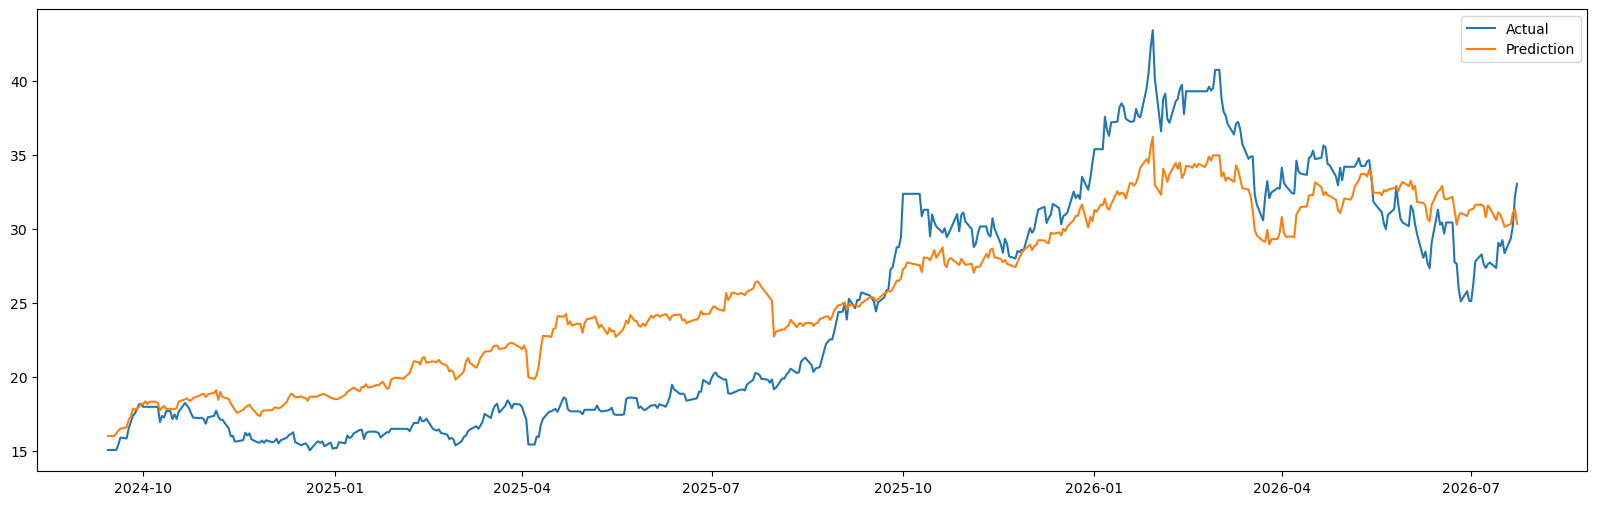

In [310]:
from sklearn import linear_model
bay = linear_model.BayesianRidge()
test_model(bay)


In [311]:
def test_model_scaled(model):
    model.fit(X_train_scaled, Y_train)
    Y_pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
    r2 = r2_score(Y_test, Y_pred)



    print("测试集 RMSE：", rmse)
    print("测试集 R²：", r2)
    
    plt.figure(figsize=(20,6))
    plt.plot(Y_test.index, Y_test, label='Actual')
    plt.plot(Y_test.index, Y_pred, label='Prediction')
    plt.legend()
    plt.show()

测试集 RMSE： 3.678092925837687
测试集 R²： 0.7901409005663905


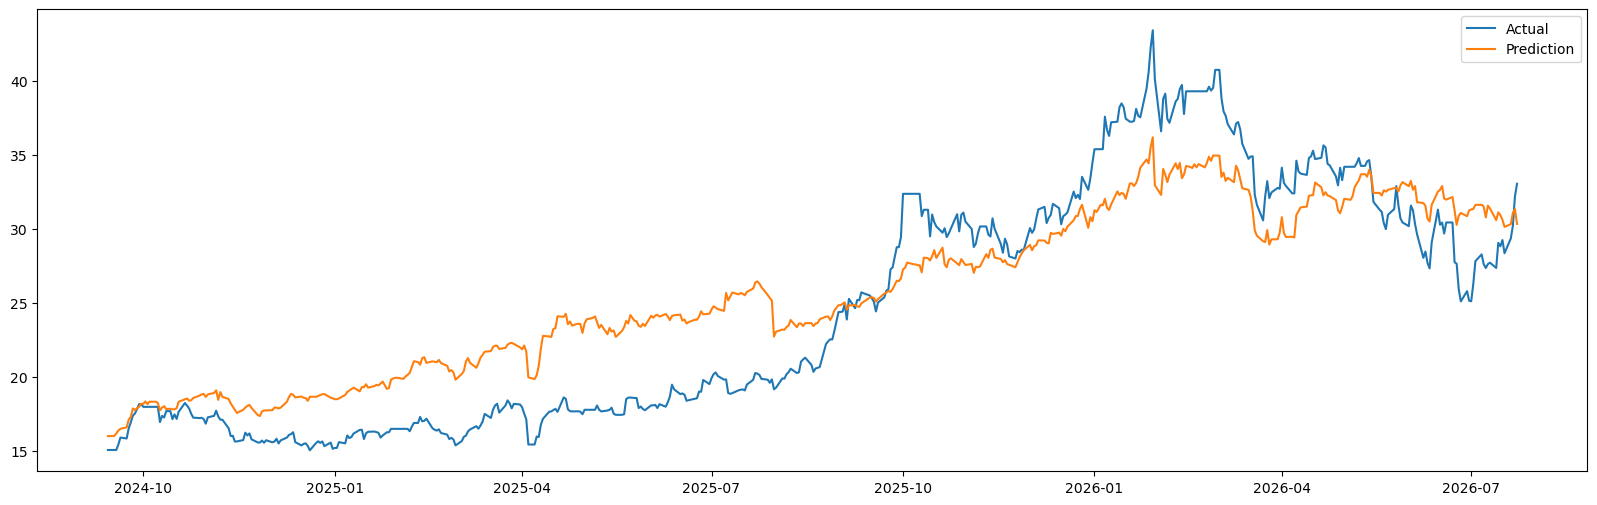

In [312]:
bay = linear_model.BayesianRidge()
test_model_scaled(bay)

没必要继续探究了.正则化影响不大.

## 6 Gradient Boosting Regressor

这个模型也是树模型,用后一个树来修正前一个树的偏误,对于未见过的情况难以推理.

测试集 RMSE： 10.122281680827921
测试集 R²： -0.589422100028071


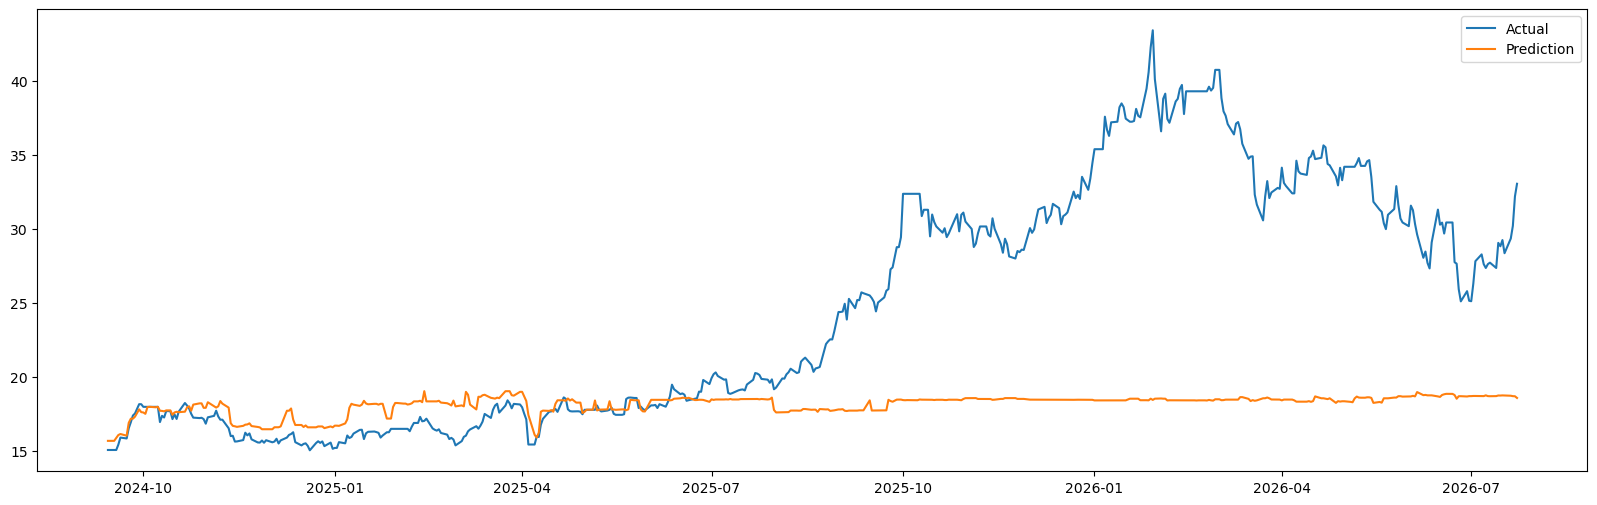

In [313]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=0
 )
test_model(gbr)

与预想中相同,直接跳过.

## 7 SGD

随机梯度下降每次拿一定的样本进行梯度下降,以最小偏差为准.需要多次调参,找出最好的结果.

测试集 RMSE： 3.6796256366664855
测试集 R²： 0.7899659619015207


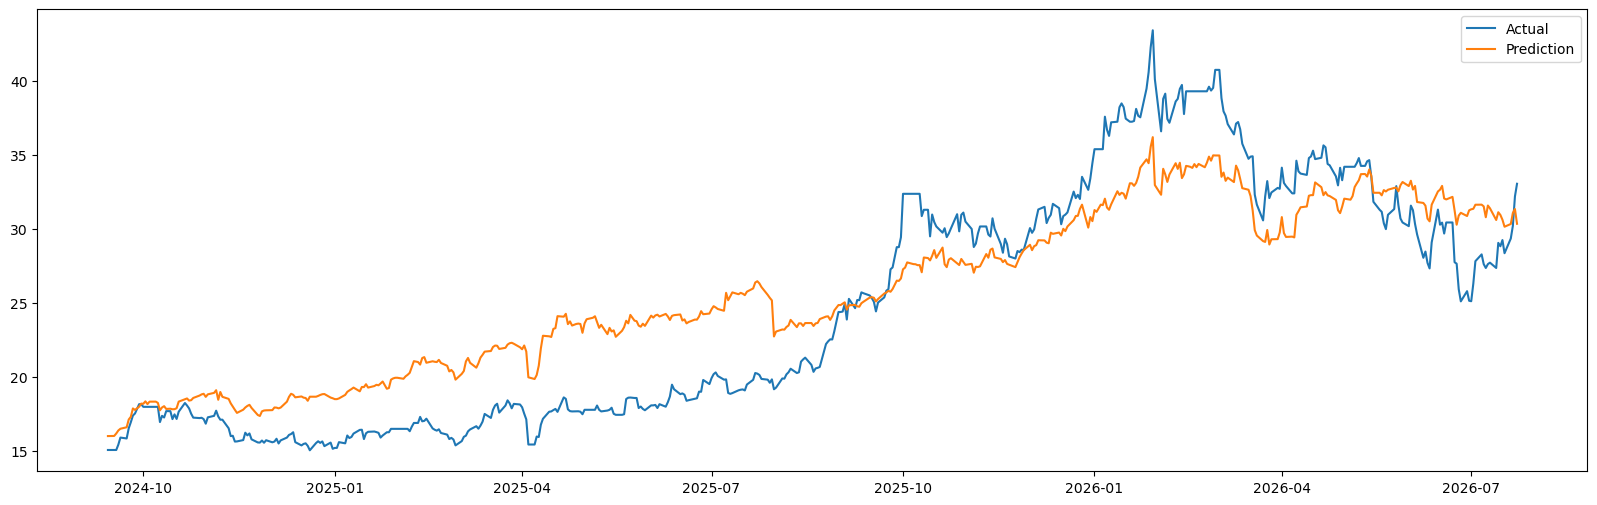

In [321]:
from sklearn.linear_model import SGDRegressor

sgd = SGDRegressor(
    learning_rate='adaptive',
    eta0=0.01,
    max_iter=10000,
    penalty='l1'
)

test_model_scaled(sgd)

效果似乎也没有区别.

---

# 结论

综上所述,用于训练参数的方法已经没有太大区别,模型基本R^2都停留在0.79左右.

我们应该放弃决策树相关的算法,对于没有见过的新情况,无法外推.

对于2024年-2026年的情况,我们把债券收益率和铜价给忽略掉,表现反而最好.我认为是正好历史训练中给了黄金更大的系数,符合当下的情况.但是我认为,黄金是不生息资产,债券利率会影响资金流向与风险偏好,不应该舍去.

此外,近年的情况应该与情绪相关.紫金矿业被称为"散户的大本营",受情绪面和技术面等影响.能否在找出一些其他因子来解释这段时间的差距?

---

In [322]:
Dataset = pd.Series({
    'X' : X,
    'Y' : Y,
}
)
pd.to_pickle(Dataset, './src/pickle/Dataset.pkl')